# Proyecto Integrador — Machine Learning  
## Módulo: Machine Learning | Soy Henry

**Estudiante:** Vanina Cavallin  
**Proyecto:** Predicción de Churn de Clientes  
**Empresa ficticia:** FinanceGuard  
**Avance:** Nº 1 — Integración y Cierre  

**Fecha:** 09/02/2026  

---

# Consigna:

1. Comprensión del problema y análisis exploratorio básico:
- Investigar qué es el churn bancario- 
- Carga y exploración inicial del dataset (50,000 clientes).
- Variables demográficas: edad, género, ubicación, antigüedad.
- Variables financieras: saldo promedio, productos contratados, transacciones.
- Variable objetivo: churn (1 = abandonó, 0 = activo).
- Análisis de desbalanceo de clases (típicamente 80-20).

2. Preparación de datos para regresión logística:
- Tratamiento de valores faltantes básico.
- Encoding de variables categóricas (One-Hot, Label Encoding).
- Escalamiento de variables numéricas (StandardScaler).
- Split básico: train (80%), test (20%).
- Identificación de multicolinealidad.

3. Implementación de Regresión Logística:
- Regresión Logística Simple:
    - Implementación desde cero (opcional).
    - Uso de scikit-learn.
    - Interpretación de la función sigmoide.
- Análisis de coeficientes:
    - Interpretación de pesos/coeficientes.
    - Odds ratios y su significado.
    - Intervalos de confianza.
- Evaluación específica:
    - Matriz de confusión.
    - Curva ROC y AUC.
    - Precision, Recall, F1-Score.

Entregar el notebook 1_EDA_RegresionLogistica.ipynb donde se realice un análisis exploratorio (EDA) básico, un procesamiento de los datos básico, y los resultados de la implementación de la regresión logística.


#### El *churn bancario* se refiere a la *pérdida de clientes* que dejan de operar con una entidad financiera. En este trabajo, la variable **Exited** indica si un cliente abandonó el banco (1) o permanece activo (0).

---

## 1) Carga y exploración inicial del dataset.
#### Carga de las librerías que se utilizarán en el análisis.

In [2]:
import pandas as pd # Manipulación de datos.
import numpy as np # Operaciones matemáticas y estadísticas.
import matplotlib.pyplot as plt # Visualización de datos
import seaborn as sns # Visualización de datos avanzada

#### Importación y lectura de los datos. 

In [3]:
# Carga el conjunto de datos desde un archivo .csv.
df_churn = pd.read_csv("Churn_Modelling.csv") 

# Muestra las primeras 10 filas del DataFrame.
display(df_churn.head(10)) 

# Quiero conocer las dimensiones del DataFrame, para lo cual utilizo la función ".shape".
print("Dimensiones del DataFrame:", df_churn.shape)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,7,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,9,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,10,15592389,H?,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


Dimensiones del DataFrame: (10000, 14)


---

## 2) Análisis exploratorio del dataset

In [4]:
# ======================================================
# Análisis Exploratorio de Datos (EDA)
# ======================================================

print("=" * 60)
print("1. ANÁLISIS EXPLORATORIO DE DATOS")
print("=" * 60)

# Información general
print("\nInformación del Dataset:")
print(f"Número de registros: {len(df_churn)}")
print(f"Número de variables: {len(df_churn.columns)}")

# Identificar tipos de variables
variables_categoricas = df_churn.select_dtypes(include='object').columns.tolist() # Clasifica por tipo de dato "object"
print(f"Variables categóricas:", variables_categoricas)
print(f"Número de variables categóricas:", len(variables_categoricas))

# Identificar columnas numéricas
variables_numericas = df_churn.select_dtypes(include='number').columns.tolist() # Clasifica por tipo de dato "number"
print("Variables numéricas:", variables_numericas)
print("Número de variables numéricas:", len(variables_numericas))
print("\nValores nulos por columna:")
print(df_churn.isnull().sum())

# Estadísticas descriptivas
print("\nEstadísticas Descriptivas:")
print(df_churn.describe().round(2))

# ======================================================

1. ANÁLISIS EXPLORATORIO DE DATOS

Información del Dataset:
Número de registros: 10000
Número de variables: 14
Variables categóricas: ['Surname', 'Geography', 'Gender']
Número de variables categóricas: 3
Variables numéricas: ['RowNumber', 'CustomerId', 'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']
Número de variables numéricas: 11

Valores nulos por columna:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Estadísticas Descriptivas:
       RowNumber   CustomerId  CreditScore       Age    Tenure    Balance  \
count   10000.00     10000.00     10000.00  10000.00  10000.00   10000.00   
mean     5000.50  15690940.57       650.53     38.92      5.01   76485.89   

C:\Users\vanin\AppData\Local\Temp\ipykernel_16036\1826595519.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  variables_categoricas = df_churn.select_dtypes(include='object').columns.tolist() # Clasifica por tipo de dato "object"


---

## 3) Estadísticas descriptivas

In [5]:
# ======================================================
# Estadísticas descriptivas que incluyen todas las columnas (numéricas y categóricas) del DataFrame
# ======================================================

display(df_churn.describe(include='all'))

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000,10000.000000,10000,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
unique,NaN,NaN,2932,NaN,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Smith,NaN,France,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,32,NaN,5014,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,5000.50000,1.569094e+07,NaN,650.528800,NaN,NaN,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,NaN,96.653299,NaN,NaN,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,NaN,350.000000,NaN,NaN,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,NaN,584.000000,NaN,NaN,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,NaN,652.000000,NaN,NaN,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,NaN,718.000000,NaN,NaN,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000


---

## 4) Distribución de las variables cuantitativas: representación con gráfico de frecuencias (histograma).

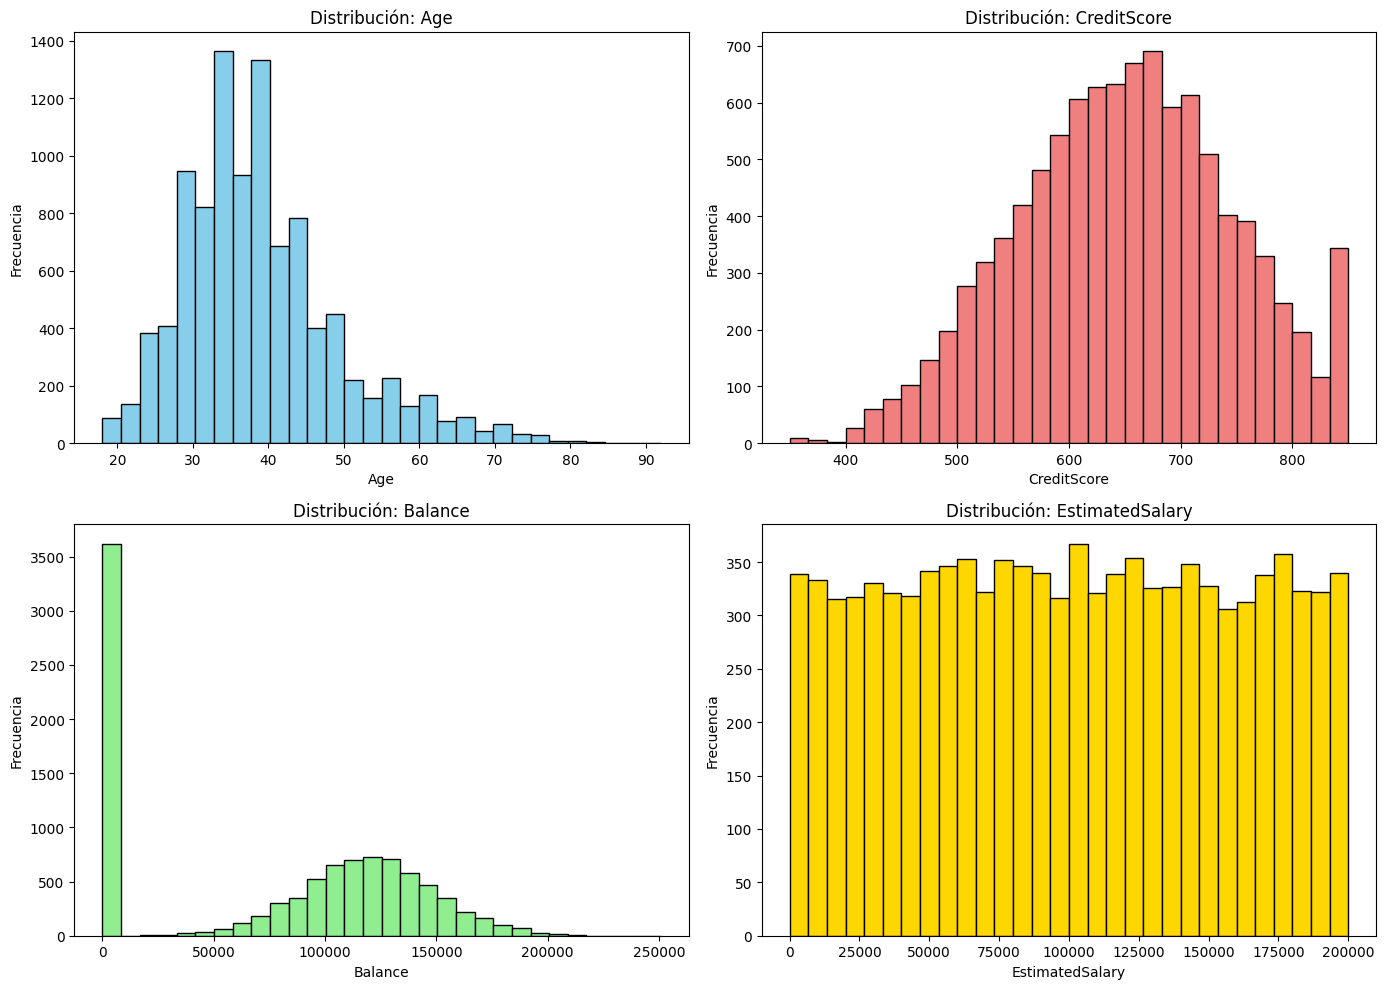

In [ ]:
# ======================================================
# Distribución de variables cuantitativas continuas
# ======================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

num_continuas = [
    'Age', 
    'CreditScore', 
    'Balance', 
    'EstimatedSalary'
    ]

axes[0, 0].hist(df_churn['Age'], bins=30, edgecolor='black', color='skyblue')
axes[0, 0].set_title('Distribución: Age')
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Frecuencia')

axes[0, 1].hist(df_churn['CreditScore'], bins=30, edgecolor='black', color='lightcoral')
axes[0, 1].set_title('Distribución: CreditScore')
axes[0, 1].set_xlabel('CreditScore')
axes[0, 1].set_ylabel('Frecuencia')

axes[1, 0].hist(df_churn['Balance'], bins=30, edgecolor='black', color='lightgreen')
axes[1, 0].set_title('Distribución: Balance')
axes[1, 0].set_xlabel('Balance')
axes[1, 0].set_ylabel('Frecuencia')

axes[1, 1].hist(df_churn['EstimatedSalary'], bins=30, edgecolor='black', color='gold')
axes[1, 1].set_title('Distribución: EstimatedSalary')
axes[1, 1].set_xlabel('EstimatedSalary')
axes[1, 1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

---

## 5) Boxplots para detectar valores atípicos (outliers)

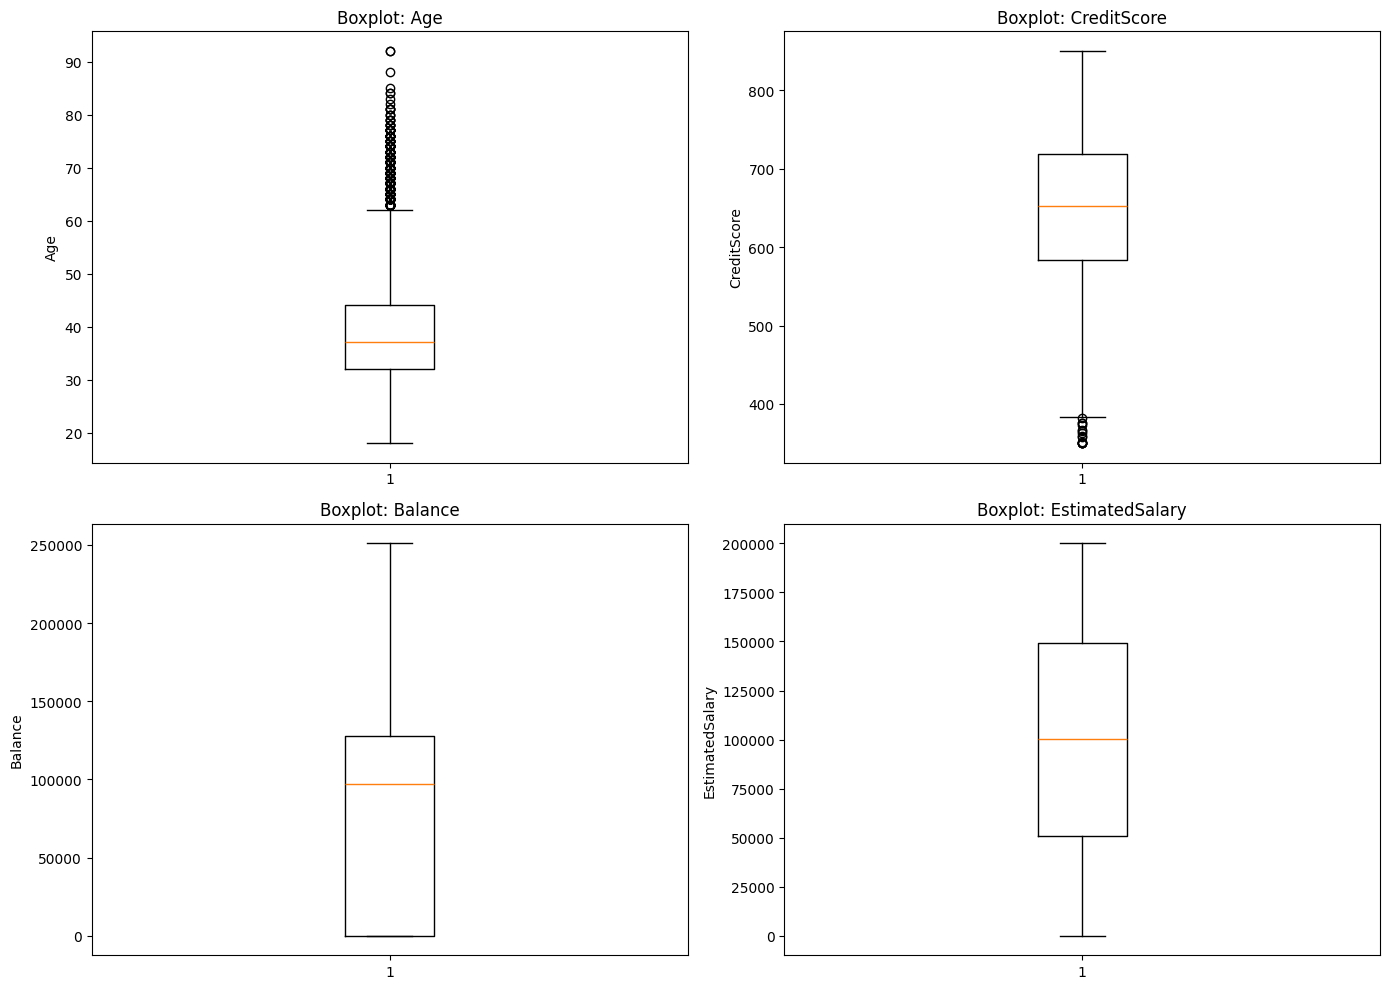

In [7]:
# ======================================================
# Boxplots para detectar outlier
# ======================================================

num_continuas = [
    'Age', 
    'CreditScore', 
    'Balance', 
    'EstimatedSalary'
    ]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].boxplot(df_churn['Age'])
axes[0, 0].set_title('Boxplot: Age')
axes[0, 0].set_ylabel('Age')

axes[0, 1].boxplot(df_churn['CreditScore'])
axes[0, 1].set_title('Boxplot: CreditScore')
axes[0, 1].set_ylabel('CreditScore')

axes[1, 0].boxplot(df_churn['Balance'])
axes[1, 0].set_title('Boxplot: Balance')
axes[1, 0].set_ylabel('Balance')

axes[1, 1].boxplot(df_churn['EstimatedSalary'])
axes[1, 1].set_title('Boxplot: EstimatedSalary')
axes[1, 1].set_ylabel('EstimatedSalary')

plt.tight_layout()
plt.show()

---

## 6) VARIABLES NUMÉRICAS DISCRETAS: las represento con gráficos de barra.

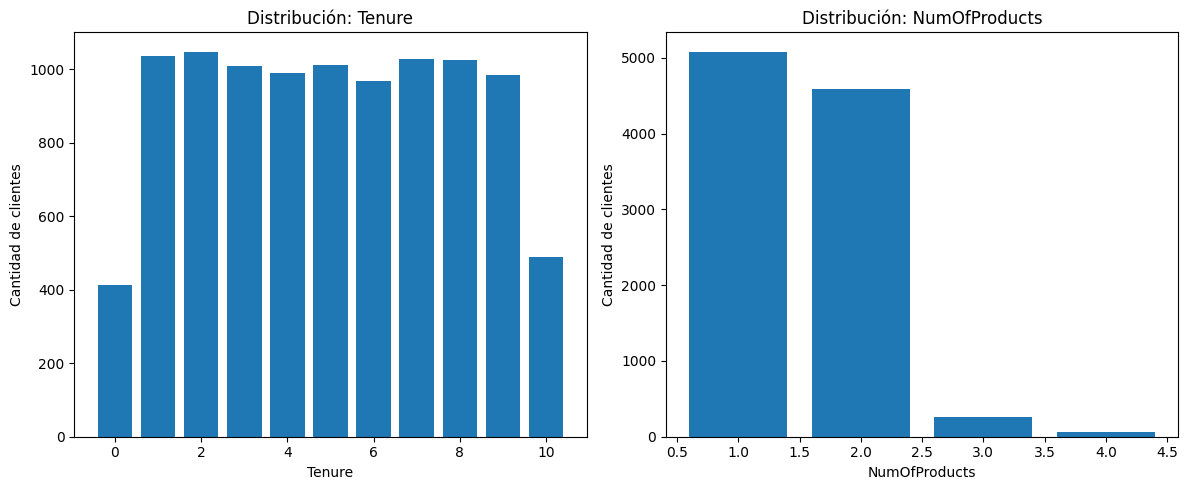

In [8]:
# ======================================================
# Distribución de variables discretas
# ======================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Tenure ---
tenure_counts = df_churn['Tenure'].value_counts().sort_index()
axes[0].bar(tenure_counts.index, tenure_counts.values)
axes[0].set_title('Distribución: Tenure')
axes[0].set_xlabel('Tenure')
axes[0].set_ylabel('Cantidad de clientes')

# --- NumOfProducts ---
products_counts = df_churn['NumOfProducts'].value_counts().sort_index()
axes[1].bar(products_counts.index, products_counts.values)
axes[1].set_title('Distribución: NumOfProducts')
axes[1].set_xlabel('NumOfProducts')
axes[1].set_ylabel('Cantidad de clientes')

plt.tight_layout()
plt.show()


#### Tenure y NumOfProducts son variables numéricas discretas con pocos valores posibles, por lo que se optó por gráficos de barras para visualizar claramente la cantidad de clientes en cada categoría.

---

## 7) Ditribución de variables binarias

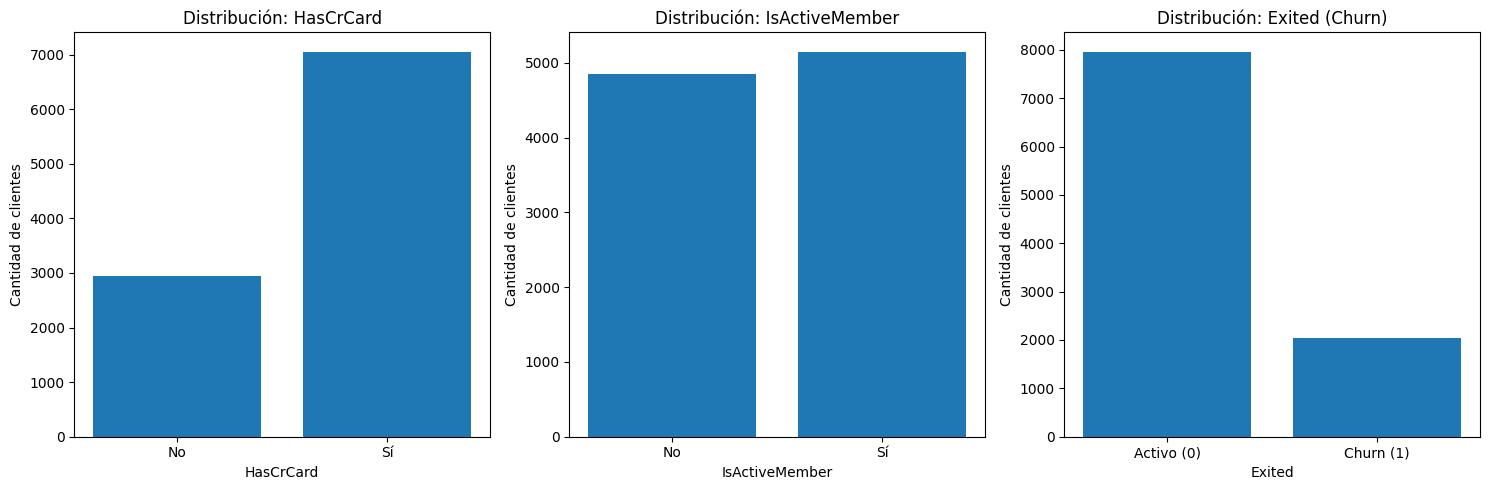

In [9]:
# ======================================================
# Distribución de variables binarias
# ======================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# --- HasCrCard ---
card_counts = df_churn['HasCrCard'].value_counts().sort_index()
axes[0].bar(card_counts.index, card_counts.values)
axes[0].set_title('Distribución: HasCrCard')
axes[0].set_xlabel('HasCrCard')
axes[0].set_ylabel('Cantidad de clientes')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['No', 'Sí'])

# --- IsActiveMember ---
active_counts = df_churn['IsActiveMember'].value_counts().sort_index()
axes[1].bar(active_counts.index, active_counts.values)
axes[1].set_title('Distribución: IsActiveMember')
axes[1].set_xlabel('IsActiveMember')
axes[1].set_ylabel('Cantidad de clientes')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['No', 'Sí'])

# --- Exited (Target) ---
churn_counts = df_churn['Exited'].value_counts().sort_index()
axes[2].bar(churn_counts.index, churn_counts.values)
axes[2].set_title('Distribución: Exited (Churn)')
axes[2].set_xlabel('Exited')
axes[2].set_ylabel('Cantidad de clientes')
axes[2].set_xticks([0, 1])
axes[2].set_xticklabels(['Activo (0)', 'Churn (1)'])

plt.tight_layout()
plt.show()


---

## 8) Distribución de variables categóricas: las represento con gráficos de barra.

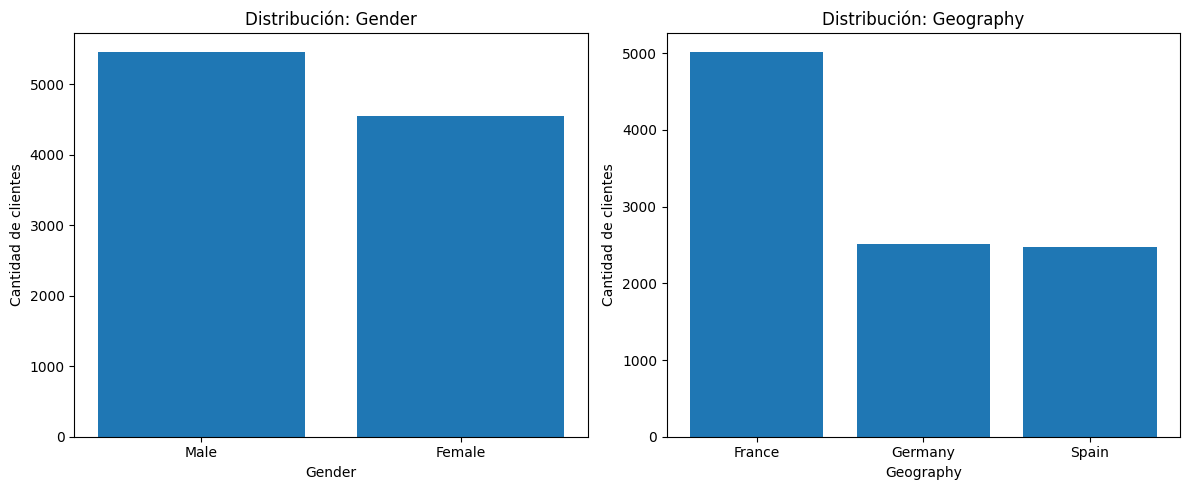

In [10]:
# ======================================================
# Distribución de variables categóricas
# ======================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Gender ---
gender_counts = df_churn['Gender'].value_counts()
axes[0].bar(gender_counts.index, gender_counts.values)
axes[0].set_title('Distribución: Gender')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Cantidad de clientes')

# --- Geography ---
geo_counts = df_churn['Geography'].value_counts()
axes[1].bar(geo_counts.index, geo_counts.values)
axes[1].set_title('Distribución: Geography')
axes[1].set_xlabel('Geography')
axes[1].set_ylabel('Cantidad de clientes')

plt.tight_layout()
plt.show()


---

## 9) ¿Cómo se comporta el churn bancario según si se trata de clientes **activos** o de aquellos **inactivos** / que usan menos el banco?
IsActiveMember:
1 → el cliente usa activamente el banco, es decir, hace transacciones, se mueve, interactúa
0 → cliente pasivo ó inactivo (en la práctica bancaria, los clientes inactivos son clientes en riesgo).

#### **Interpretación:** Se observa que los clientes inactivos (0) presentan una mayor proporción de churn en comparación con los clientes activos (1), lo que sugiere que la actividad transaccional es un factor relevante en la decisión de abandono.

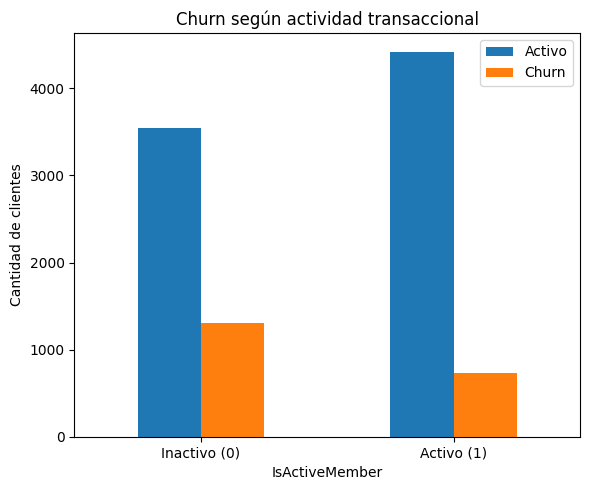

In [11]:
# ======================================================
# Churn vs Actividad transaccional
# ======================================================

active_churn = (
    df_churn
    .groupby('IsActiveMember')['Exited']
    .value_counts()
    .unstack()
)

fig, ax = plt.subplots(figsize=(6, 5))

active_churn.plot(kind='bar', ax=ax)
ax.set_title('Churn según actividad transaccional')
ax.set_xlabel('IsActiveMember')
ax.set_ylabel('Cantidad de clientes')
ax.set_xticklabels(['Inactivo (0)', 'Activo (1)'], rotation=0)
ax.legend(['Activo', 'Churn'])

plt.tight_layout()
plt.show()


---

## 10) Proporción de los datos

In [12]:
# Conteo de la variable objetivo
churn_counts = df_churn['Exited'].value_counts().sort_index()

print(churn_counts)

Exited
0    7963
1    2037
Name: count, dtype: int64


---

## 11) Gráfico de barras para representar el churn bancario

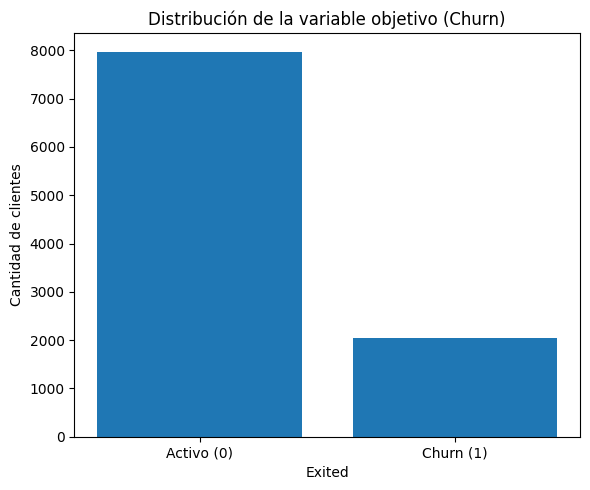

In [13]:
# ======================================================
# Representación gráfica del conteo de la variable objetivo (Exited)
# ======================================================
 
fig, ax = plt.subplots(figsize=(6, 5))

ax.bar(churn_counts.index, churn_counts.values)
ax.set_title('Distribución de la variable objetivo (Churn)')
ax.set_xlabel('Exited')
ax.set_ylabel('Cantidad de clientes')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Activo (0)', 'Churn (1)'])

plt.tight_layout()
plt.show()


#### Observación: existe un desbalance de clases típico en problemas de churn bancario, donde la mayoría de los clientes permanece activa. Este desbalance debe ser tenido en cuenta al momento de evaluar el modelo, ya que métricas como accuracy pueden resultar engañosas.
#### Análisis de desbalanceo de clases (típicamente 80-20)
#### Vriable objetivo: Exited (churn)
#### Exited = 1 → cliente abandonó
#### Exited = 0 → cliente activo
#### Interpretación: El dataset presenta un desbalance moderado de clases, con aproximadamente un 80% de clientes activos y un 20% que abandonaron.

---

## 12) Detección de valores faltantes

In [14]:
# Detección de valores faltantes en el DataFrame
df_churn.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

> No se detectaron valores nulos en ninguna de las variables, por lo que no fue necesario aplicar técnicas de imputación.

---
## 13) Encoding para variables discretas

In [15]:
variables_categoricas_nominales = ['Gender', 'Geography']

In [16]:
df_encoded = pd.get_dummies( # Transforma una variable categórica en columnas binarias (0 / 1).
    df_churn,
    columns=variables_categoricas_nominales,
    drop_first=True # Deja fuera la primera categoría para evitar multicolinealidad.
)

df_encoded.head()

,RowNumber,CustomerId,Surname,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Gender_Male,Geography_Germany,Geography_Spain
0,1,15634602,Hargrave,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,2,15647311,Hill,608,41,1,83807.86,1,0,1,112542.58,0,False,False,True
2,3,15619304,Onio,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,4,15701354,Boni,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,5,15737888,Mitchell,850,43,2,125510.82,1,1,1,79084.10,0,False,False,True


---

## 14) 
#### a. Escalado de variables.
#### b. Definición de la variable target y la variable objetivo.

In [17]:
# Defino las variables numéricas a escalar

num_vars = [
    'Age',
    'CreditScore',
    'Balance',
    'EstimatedSalary',
    'Tenure',
    'NumOfProducts'
]

In [18]:
# Defino la variable respuesta u objetivo.
y = df_encoded['Exited']

# Defino variables predictoras eliminando columnas irrelevantes.
X = df_encoded.drop(columns=['Exited', 'RowNumber', 'CustomerId', 'Surname']) 

---

## 15) División del dataset en:
- Train → entrena el modelo.
- Test → evalúa qué tan bien generaliza el modelo.

**Se respeta la proporción 80/20, usando el 20% para test, de forma reproducible, y manteniendo la proporción de clientes que abandonan y que no.**

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, # Variables predictporas o explicativas.
    y, # Variable respuesta u objetivo.
    test_size=0.2, # 20% de los datos son para test. El 80% restante para entrenamiento.
    random_state=42, # Aleatoriedad controlada para su reproducibilidad.
    stratify=y # Mantiene la proporción de clases en ambos conjuntos (train y test).
)

In [20]:
# Definición de variables numéricas a escalar
variables_num= [
    'Age',
    'CreditScore',
    'Balance',
    'EstimatedSalary',
    'Tenure',
    'NumOfProducts'
]

---

## 16) Generación de copias de los conjuntos de datos de entrenamiento y prueba, como buena práctica antes de escalarlos.

In [21]:
# Importo librería.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler() # Crea el objeto escalador.

# Generación de copias para evitar modificar los datos originales.
X_train_scaled = X_train.copy() 
X_test_scaled = X_test.copy()

# Escalado de las copias.
# Función fit_transform a los datos de entrenamiento: fit calcula media y desvío y transform aplica esa transformación.
X_train_scaled[variables_num] = scaler.fit_transform(X_train[variables_num]) 

# Función transform: aplica la transformación calculada en el train al conjunto de datos de test.
X_test_scaled[variables_num] = scaler.transform(X_test[variables_num])

---

## 17) Escalado de variables: Las variables numéricas fueron escaladas mediante StandardScaler, ajustado únicamente sobre el conjunto de entrenamiento y aplicado luego al conjunto de test, evitando fuga de información. Las variables dummy no fueron escaladas para preservar su interpretación binaria

In [ ]:
%pip install statsmodels

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.5 MB 2.5 MB/s eta 0:00:04
   ----- ---------------------------------- 1.3/9.5 MB 2.4 MB/s eta 0:00:04
   ------- -------------------------------- 1.8/9.5 MB 2.6 MB/s eta 0:00:04
   --------- ------------------------------ 2.4/9.5 MB 2.5 MB/s eta 0:00:03
   ------------ --------------------------- 2.9/9.5 MB 2.5 MB/s eta 0:00:03
   --------------- ------------------------ 3.7/9.5 MB 2.7 MB/s eta 0:00:03
   ---------------- ----------------------- 3.9/9.5 MB 2.6 MB/s eta 0:00:03
   ------------------ --------------------- 4.5/9.5 MB 2.5 MB/s eta 0:00:03
   -------------------- ------------------- 5.0/9.5 MB 2.6 MB/s eta 0:00:02
   --------------------- ------------------ 5.2/9.5 MB 2.5 MB/s eta 0:00:02
   ------------------------ --------------- 5.8/9.5 MB 2.5 MB/s eta 0:00:02
   -----------------------


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


---

## 18) Cálculo de VIF (Variance Inflation Factor)

In [22]:
# Importar librería que calcula el VIF.
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [23]:
# Generación de una copia de los datos escalados de entrenamiento para el cálculo del VIF.
X_vif = X_train_scaled.copy()

# Garantizo que todas las columnas sean de tipo numérico
X_vif = X_vif.astype(float)

In [24]:
X_vif = X_vif.loc[:, X_vif.var() != 0]

In [45]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_df = pd.DataFrame()
vif_df["Variable"] = X_vif.columns
vif_df["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif_df = vif_df.sort_values("VIF", ascending=False)
vif_df


,Variable,VIF
5,HasCrCard,2.199246
8,Gender_Male,1.840011
6,IsActiveMember,1.766403
9,Geography_Germany,1.576919
10,Geography_Spain,1.353279
3,Balance,1.323378
4,NumOfProducts,1.124391
1,Age,1.011548
2,Tenure,1.002311
7,EstimatedSalary,1.001234


### Regla:

| VIF    | Interpretación     |
| ------ | ------------------ |
| ≈ 1    | Sin colinealidad   |
| 1 – 5  | Aceptable          |
| 5 – 10 | Atención           |
| > 10   | Colinealidad grave |

#### En la tabla el VIF más alto es HasCrCard ≈ 2.20. Le sigue Gender_Male ≈ 1.84 y el resto está muy cerca de 1.

#### Conclusión: Se evaluó la multicolinealidad entre variables explicativas mediante el Variance Inflation Factor (VIF). Los valores obtenidos se encontraron dentro de rangos aceptables, por lo que no fue necesario eliminar variables del modelo. Ninguna variable presenta colinealidad relevante. A lo sumo, HasCrCard y Gender_Male muestran una colinealidad leve, totalmente aceptable y no problemática para modelos de regresión. No hace falta eliminar variables por colinealidad 

---

## 19) Creación del modelo de Regresión Logística

In [25]:
# importación de librería necesaria para implementar el modelo de regresión logística
from sklearn.linear_model import LogisticRegression

regresion_logistica = LogisticRegression(
    max_iter=1000, # Máximo número de iteraciones.
    solver='lbfgs' # Algoritmo de optimización: se utiliza para encontrar los coeficientes que mejor ajustan el modelo.
)

# Entrenamiento del modelo.
# La función fit busca la mejor combinación de variables 
# (edad, balance, productos, etc.) que explique la probabilidad de que un cliente se vaya del banco.
# El modelo: Toma 'X_train_scaled' e 'y_train' y aprende los coeficientes (pesos) y el intercepto.
# Internamente: Calcula la combinación lineal, aplica la sigmoide y ajusta pesos para minimizar errores

regresion_logistica.fit(X_train_scaled, y_train) 

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

#### Utilización de las funciones 'predict' y 'predict_proba'

| Método             | Devuelve                      |
| ------------------ | ----------------------------- |
| `.predict()`       | Clase final (0 ó 1)           |
| `.predict_proba()` | Probabilidad (nº entre 0 y 1) |

In [26]:
# Clasificación de los clientes 'y_pred' en 0 y 1. 
y_pred = regresion_logistica.predict(X_test_scaled)
# Cálculo de la probabilidad de que abandonen el banco.
y_pred_proba = regresion_logistica.predict_proba(X_test_scaled)[:, 1]

---

## 20) Extracción de los coeficientes de cada variable para ubicarlos en una tabla

In [29]:
# Extracción e interpretación de los coeficientes del modelo.
coef_df = pd.DataFrame({
    'Variable':
      X_train_scaled.columns, 
    'Coeficiente': 
      regresion_logistica.coef_[0]
      })

coef_df = coef_df.sort_values('Coeficiente', ascending=True) # "sort_values": ordeno los coeficientes de forma creciente.
coef_df

,Variable,Coeficiente
6,IsActiveMember,-1.028157
8,Gender_Male,-0.523155
0,CreditScore,-0.085893
5,HasCrCard,-0.070516
4,NumOfProducts,-0.070423
2,Tenure,-0.020096
10,Geography_Spain,0.042508
7,EstimatedSalary,0.047666
3,Balance,0.161093
1,Age,0.738453


---

## 21) Cálculo de Odds ratio

In [ ]:
# ODDS RATIO:
coef_df['Odds_Ratio'] = np.exp(coef_df['Coeficiente'])
coef_df

,Variable,Coeficiente,Odds_Ratio
6,IsActiveMember,-1.028157,0.357665
8,Gender_Male,-0.523155,0.592648
0,CreditScore,-0.085893,0.917692
5,HasCrCard,-0.070516,0.931913
4,NumOfProducts,-0.070423,0.931999
2,Tenure,-0.020096,0.980105
10,Geography_Spain,0.042508,1.043424
7,EstimatedSalary,0.047666,1.048820
3,Balance,0.161093,1.174794
1,Age,0.738453,2.092695


---

## 22) Elaboración de una matriz de confusión para la evaluación del modelo
¿Qué es la matriz de confusión? Es una tabla que compara lo real (y_test) y lo que predijo el modelo (y_pred).

**Para churn:**

|                       | Predijo NO churn (0) | Predijo churn (1) |
| --------------------- | -------------------- | ----------------- |
| **Real NO churn (0)** | TN                   | FP                |
| **Real churn (1)**    | FN                   | TP                |

In [31]:
# Matriz de confusión.
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
cm

array([[1540,   53],
       [ 331,   76]])

---

## 23) Interpretación de la matriz de  confusión:

- 1540 clientes bien clasificados como activos
- 53 *falsos positivos* (falsas alarmas) ❌
- 331 churn que NO detectaste ❌ (grave en negocio)
- 76 *verdaderos positivos* - churn detectados ✔️

En el churn, **los FN son los más caros.**

#### Interpretación de las métricas

🔹 Precision: De los que predije como churn, ¿cuántos realmente lo eran?
- Alta precision → pocas falsas alarmas (53 *falsos positivos*)
- Baja precision → muchas falsas alarmas

🔹 Recall (crítico en churn bancario): De todos los churn reales, ¿cuántos detecté?
- Recall bajo → estás dejando ir clientes sin enterarte (331 *churn que NO detectaste*)
- Recall alto → detectás bien a los que se van (*verdaderos positivos*).

🔹 F1-score: Promedio armónico entre precision y recall. Útil cuando las clases están desbalanceadas. Resume performance en una sola métrica.

🔹 Support: Cantidad de observaciones reales por clase. Ejemplo: 
0 → 1593
1 → 407

**Esto refleja el split 80/20**

---

## 24) Hiperparámetros:
- Precisión.
- Recall.
- F1-Score.
- Support

In [32]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



| Fila                    | Significado                        |
| ----------------------- | ---------------------------------- |
| **0**                   | Clientes que **NO hicieron churn** |
| **1**                   | Clientes que **SÍ hicieron churn** |
| **accuracy / averages** | Resúmenes globales                 |

🔹 support:
    0 → 1593
    1 → 407
*Interpretación:* En el conjunto de test (2000 clientes):
    1593 no se fueron (≈ 80%)
    407 sí se fueron (≈ 20%)

🔹 Precision (¿qué tan confiable es la alarma?)
    Clase 1 (churn):
    precision = 0.59
*Interpretación:* De todos los clientes que el modelo indicó churn, sólo el 59% **realmente se fue**.
El 41% restante: fueron falsas alarmas o contactar clientes que igual se iban a quedar.

🔹 Recall (la métrica más importante acá)
    Clase 1 (churn):
    recall = 0.19
*Interpretación:* De todos los clientes que realmente se fueron, el modelo sólo detectó el 19%. Esto es muy bajo🚨 
Básicamente, al 81% de los clientes que se fueron el modelo **no los vió venir**.

🔹 F1-score (balance entre ambas)
    Clase 1:
    f1-score = 0.28
*Interpretación:* Precision mediocre. Un F1 tan bajo indica que el modelo es poco útil para detectar churn.

En cambio, para la Clase 0:
precision = 0.82
recall = 0.97
f1-score = 0.89
*Interpretación:* Precision buena. El mmodelo es muy bueno detectando a los clientes que se quedan 
(aunque eso no sea lo que nos importa ahora).

---

#### **INTERPRETACIÓN FINAL:** El modelo aprende muy bien quiénes se quedan, pero falla muchísimo en detectar **quiénes se van**.
#### Esto es normal cuando se tienen:
- clases desbalanceadas.
- umbral 0.5.
- regresión logística básica.

---

## 25) Cálculo de AUC

In [33]:
from sklearn.metrics import roc_curve, roc_auc_score

auc = roc_auc_score(y_test, y_pred_proba)
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

print("AUC:", auc)

AUC: 0.774824130756334


> ## Conclusión integradora: El modelo presenta un buen poder de discriminación (AUC ≈ 0.77), pero un bajo recall para la clase churn, indicando que el umbral de clasificación prioriza la clase mayoritaria y resulta inadecuado para detectar abandonos.